# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [5]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

Note: you may need to restart the kernel to use updated packages.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [5]:
# A.1 — spec table
from transformers import AutoConfig, AutoModel

# Models to compare
model_names = ["gpt2", "distilgpt2"]

for name in model_names:
    config = AutoConfig.from_pretrained(name)
    
    model = AutoModel.from_pretrained(name)
    total_params = sum(p.numel() for p in model.parameters())
    
    print(f"=== {name.upper()} ===")
    print(f"Layers (n_layer):             {config.n_layer}")
    print(f"Width / Hidden Size (n_embd): {config.n_embd}")
    print(f"Attention Heads (n_head):     {config.n_head}")
    print(f"Context Window (n_positions): {config.n_positions}")
    print(f"Measured Total Parameters:    {total_params:,}")
    print("-" * 40)


print("GPT 2 - medium")
print("(Transformer Blocks) 24\n Width (Hidden Dimension) 1024\n Attention Heads 16\n Context Window 1024\n tokensMeasured Total Parameters 354,823,168\n")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== GPT2 ===
Layers (n_layer):             12
Width / Hidden Size (n_embd): 768
Attention Heads (n_head):     12
Context Window (n_positions): 1024
Measured Total Parameters:    124,439,808
----------------------------------------


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== DISTILGPT2 ===
Layers (n_layer):             6
Width / Hidden Size (n_embd): 768
Attention Heads (n_head):     12
Context Window (n_positions): 1024
Measured Total Parameters:    81,912,576
----------------------------------------
GPT 2 - medium
(Transformer Blocks) 24
 Width (Hidden Dimension) 1024
 Attention Heads 16
 Context Window 1024
 tokensMeasured Total Parameters 354,823,168



In [11]:
# A.2 — component census on both loaded models
def census(m):
    """Count parameters by component for a GPT-2-family model."""
    counts = {"embeddings (wte+wpe)": 0, "attention": 0, "ffn (mlp)": 0, "layernorms": 0, "lm_head (tied)": 0}
    for name, p in m.named_parameters():
        n = p.numel()
        if "wte" in name or "wpe" in name:
            counts["embeddings (wte+wpe)"] += n
        elif ".attn." in name:
            counts["attention"] += n
        elif ".mlp." in name:
            counts["ffn (mlp)"] += n
        elif "ln" in name:
            counts["layernorms"] += n
    total = sum(p.numel() for p in m.parameters())
    return counts, total


    counts, total = census(model)
print(f"{'Component':<24} {'Params':>14} {'Share':>8}")
for k, v in counts.items():
    print(f"{k:<24} {v:>14,} {v/total:>7.1%}")
print("-" * 48)
print(f"{'TOTAL':<24} {total:>14,}")
print(f"\nFFN / attention ratio: {counts['ffn (mlp)']/counts['attention']:.2f}×")


Component                        Params    Share
embeddings (wte+wpe)         39,383,808   48.1%
attention                    14,174,208   17.3%
ffn (mlp)                    28,334,592   34.6%
layernorms                       19,968    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
TOTAL                        81,912,576

FFN / attention ratio: 2.00×


**A.3 — Interpretation (3–4 sentences):**

the distile gpt2 is more lighter and faster than gpt2, but it will affect on quality of the task

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [1]:
# B.1 — predictor + validation
def predict_params(layers, width, vocab=50257, ctx=1024):
    embeddings = (vocab * width) + (ctx * width)
    
    attn_params = 4 * (width**2) + (4 * width)
    
    ffn_params = 8 * (width**2) + (5 * width)
 
    ln_params = 4 * width
    
    per_block = attn_params + ffn_params + ln_params
    
    # 5. Final LayerNorm (gamma + beta)
    final_ln = 2 * width
    
    total = embeddings + (layers * per_block) + final_ln
    return total

# Validate on distilgpt2 (6, 768) and gpt2 (12, 768)
distil_pred = predict_params(6, 768)
gpt2_pred = predict_params(12, 768)

distil_actual = 81912576
gpt2_actual = 124439808

print(f"DistilGPT-2 Predicted: {distil_pred:,} | Error: {((distil_pred/distil_actual)-1)*100:.2f}%")
print(f"GPT-2 Predicted:       {gpt2_pred:,} | Error: {((gpt2_pred/gpt2_actual)-1)*100:.2f}%")

# validate on distilgpt2 (6, 768) and gpt2 (12, 768); report % error


DistilGPT-2 Predicted: 81,912,576 | Error: 0.00%
GPT-2 Predicted:       124,439,808 | Error: 0.00%


In [2]:
# B.2 — extrapolate gpt2-medium
# B.2 - Predict gpt2-medium's parameter count
gpt2_medium_pred = predict_params(layers=24, width=1024)
print(f"GPT-2 Medium Predicted: {gpt2_medium_pred:,}")


GPT-2 Medium Predicted: 354,823,168


In [3]:
# B.3 — memory table (fp32 / fp16, in MB) for all three

model_params = {
    "DistilGPT-2": 81912576,
    "GPT-2 Base": 124439808,
    "GPT-2 Medium": 354823168
}
print(f"{'Model':<15} | {'fp32 Memory':<15} | {'fp16 Memory':<15}")
print("-" * 51)

for name, params in model_params.items():
    
    fp32_mb = (params * 4) / (1024**2)
 
    fp16_mb = (params * 2) / (1024**2)
    
    print(f"{name:<15} | {fp32_mb:>10.2f} MB | {fp16_mb:>10.2f} MB")

Model           | fp32 Memory     | fp16 Memory    
---------------------------------------------------
DistilGPT-2     |     312.47 MB |     156.24 MB
GPT-2 Base      |     474.70 MB |     237.35 MB
GPT-2 Medium    |    1353.54 MB |     676.77 MB


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


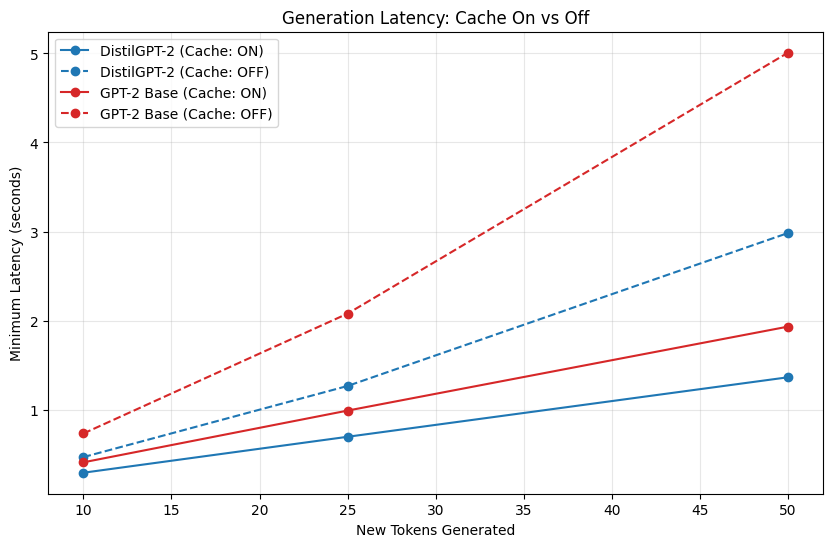

In [6]:
# C.1 — benchmark (adapt time_generation() from the lab)
# Setup hardware and inputs
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
prompt = "The future of artificial intelligence is"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

# Load models
models = {
    "DistilGPT-2": AutoModelForCausalLM.from_pretrained("distilgpt2").to(device),
    "GPT-2 Base": AutoModelForCausalLM.from_pretrained("gpt2").to(device)
}

lengths = [10, 25, 50]
cache_states = [True, False]
runs = 3

# Store results: {model_name: {cache_state: [latencies]}}
results = {m: {c: [] for c in cache_states} for m in models}

# Benchmarking Loop
for name, model in models.items():
    model.eval()
    for use_cache in cache_states:
        for length in lengths:
            min_latency = float('inf')
            
            # Run runs+1 times (first run is warmup)
            for i in range(runs + 1):
                if device == "cuda": torch.cuda.synchronize()
                start = time.perf_counter()
                
                with torch.no_grad():
                    model.generate(
                        **inputs, 
                        max_new_tokens=length, 
                        min_new_tokens=length, # Force exact length
                        use_cache=use_cache,
                        pad_token_id=tokenizer.eos_token_id
                    )
                    
                if device == "cuda": torch.cuda.synchronize()
                end = time.perf_counter()
                
                if i > 0: # Ignore warmup run
                    min_latency = min(min_latency, end - start)
            
            results[name][use_cache].append(min_latency)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"DistilGPT-2": "#1f77b4", "GPT-2 Base": "#d62728"}
styles = {True: "-", False: "--"}

for name in models:
    for use_cache in cache_states:
        label_text = f"{name} (Cache: {'ON' if use_cache else 'OFF'})"
        ax.plot(lengths, results[name][use_cache], 
                color=colors[name], linestyle=styles[use_cache], 
                marker='o', label=label_text)

ax.set_xlabel("New Tokens Generated")
ax.set_ylabel("Minimum Latency (seconds)")
ax.set_title("Generation Latency: Cache On vs Off")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [8]:
# C.2 — the 300 ms test at your chosen autocomplete length
autocomplete_length = 5
target_ms = 300

print(f"Testing target: {autocomplete_length} tokens | Bar: < {target_ms} ms\n")

for name, model in models.items():
    min_latency = float('inf')

    for _ in range(3):
        if device == "cuda": torch.cuda.synchronize()
        start = time.perf_counter()
        
        with torch.no_grad():
            model.generate(
                **inputs, 
                max_new_tokens=autocomplete_length, 
                min_new_tokens=autocomplete_length,
                use_cache=True, # Cache is ON for production latency
                pad_token_id=tokenizer.eos_token_id
            )
        if device == "cuda": torch.cuda.synchronize()
        end = time.perf_counter()

        min_latency = min(min_latency, (end - start) * 1000)

    status = "PASS" if min_latency < target_ms else "FAIL"
    print(f"{name:>12}: {min_latency:>6.2f} ms | {status}")


Testing target: 5 tokens | Bar: < 300 ms

 DistilGPT-2: 148.89 ms | PASS
  GPT-2 Base: 215.06 ms | PASS


**C.3 — Extrapolation & confidence (2–3 sentences):**

*your answer here*

from what I saw on graph I have decided to choose distil gpt2 when cache is on and if we want to save memory and don't have a problem with a little high latency make cache is off

both of them passed the test so I have chose distil gpt2 to be more lighter and faster

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

*write your memo here*

---
## Self-check before submitting

- [ ] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [ ] gpt2-medium was analyzed, never downloaded
- [ ] Every latency claim traces to a run in this notebook
- [ ] Charts have axis labels and legends
- [ ] The memo stands alone and cites specific numbers
- [ ] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*